# Mathematical Engineering - Financial Engineering, FY 2025-2026

# Buy Side - Exercise 4a: Statistical Arbitrage

Based on the paper "Statistical Arbitrage in the U.S. Equities Market" by Avellaneda & Lee (2008)


In [1]:
%load_ext autoreload
%autoreload 2

# Importing the libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.backtest import backtest
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.statistical_arbitrage import (
    estimate_factor_model,
    estimate_all_ou_parameters,
    estimate_ou_window_residuals,
    compute_s_score,
    compute_volume_adjusted_returns,
    update_positions,
    compute_strategy_statistics,
    compute_portfolio_weights,
)

In [2]:
# Reading the data
data_path = Path("data")

last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
).ffill()

# Volume data for trading-time adjustment
volume = pd.read_csv(
    data_path / "volume.csv",
    index_col="Date",
    parse_dates=True,
)

In [3]:
# RMK for who handles this variable: we get the daily simple return. Of course we need to start from line 2 since a value 
#                                    previous of the first day does not exist
performance = last_prices.pct_change().iloc[1:]

In [4]:
# Parameters
estimation_window =  252  # ERROR: it was 2 years of data for PCA factor model estimation, we are asked to do 1 year
ou_estimation_window = 60  # 60 business days for O-U estimation
n_factors = 4  # ERROR: it was 5, but in the slide and Assignment was written 4. Number of PCA factors

# Trading signal parameters
s_bo = 1.25  # Buy to open threshold:   CONTROLLA CHE CI METTA IL MENO NELLE RIGHE SEGUENTI DEL CODICE
s_so = 1.25  # Sell to open threshold
s_bc = 0.50  # Buy to close threshold: ERROR: it was 0.75, in the paper is actually 0.5
s_sc = 0.50  # Sell to close threshold

# O-U filter
min_mean_reversion_speed = 252 / 30

min_coverage = 0.95
transaction_costs = 10e-4

# 1. Understanding PCA-based Factor Models

The statistical arbitrage approach by Avellaneda & Lee uses Principal Component Analysis (PCA) to extract systematic risk factors from stock returns. The idea is:

1. **Factor Model**: Decompose each stock's return as:
   $$R_{i,t} = \alpha_i + \sum_{j=1}^{K} \beta_{i,j} F_{j,t} + \epsilon_{i,t}$$

   where $F_j$ are the principal component factors.

2. **Residual Returns**: The residuals $\epsilon_{i,t}$ represent the idiosyncratic (stock-specific) returns.

3. **Mean Reversion**: The cumulative residuals $X_{i,t} = \sum_{s=1}^{t} \epsilon_{i,s}$ are modeled as mean-reverting Ornstein-Uhlenbeck processes.


In [5]:
# Example: Estimate factor model on the first estimation window
calibration_date = None
for date in performance.index:
    candidate_window = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=date,
        lookback=estimation_window,
        min_coverage=min_coverage,
    )
    if candidate_window.shape[0] == estimation_window and candidate_window.shape[1] > 0:
        calibration_date = date
        calibration_window = candidate_window
        break

print(
    f"First estimation window: {calibration_window.index[0].date()} to {calibration_window.index[-1].date()}"
)
print(f"Number of observations: {len(calibration_window)}")
print(f"Number of assets: {calibration_window.shape[1]}")

First estimation window: 2013-01-03 to 2013-12-24
Number of observations: 252
Number of assets: 46


In [6]:
# Estimate the factor model
factor_model = estimate_factor_model(candidate_window, n_factors=n_factors)

print(f"Number of factors used: {factor_model['n_factors']}")
print("\nExplained variance by each factor:")
for i, ev in enumerate(factor_model["explained_variance"]):
    print(f"  PC{i + 1}: {ev:.2%}")
print(f"\nTotal explained variance: {factor_model['explained_variance'].sum():.2%}")

Number of factors used: 4

Explained variance by each factor:
  PC1: 43.08%
  PC2: 5.75%
  PC3: 3.91%
  PC4: 2.71%

Total explained variance: 55.44%


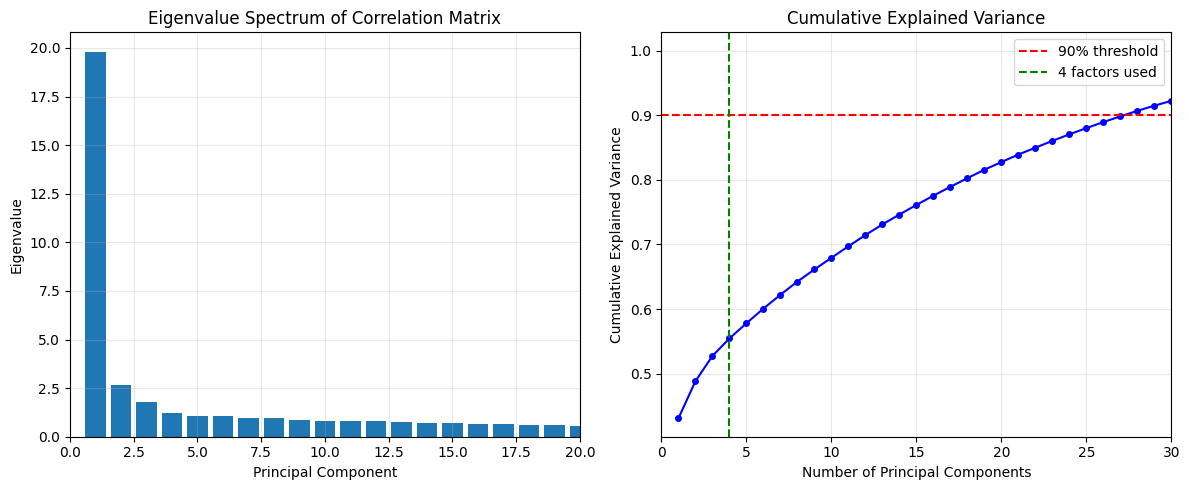

In [7]:
# Plot eigenvalue spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(factor_model["eigenvalues"]) + 1), factor_model["eigenvalues"])
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Correlation Matrix")
plt.xlim(0, 20)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_var = (
    np.cumsum(factor_model["eigenvalues"]) / factor_model["eigenvalues"].sum()
)
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, "b-o", markersize=4)
plt.axhline(y=0.9, color="r", linestyle="--", label="90% threshold")
plt.axvline(x=n_factors, color="g", linestyle="--", label=f"{n_factors} factors used")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 30)

plt.tight_layout()
plt.show()

# 2. Ornstein-Uhlenbeck Process for Residuals

The cumulative residuals are modeled as an Ornstein-Uhlenbeck (O-U) process:

$$dX_t = \kappa (m - X_t) dt + \sigma dW_t$$

where:

- $\kappa$ is the **mean-reversion speed** (how fast the process reverts to the mean)
- $m$ is the **equilibrium level** (long-term mean)
- $\sigma$ is the **volatility** of the process

The **equilibrium standard deviation** is: $\sigma_{eq} = \frac{\sigma}{\sqrt{2\kappa}}$

The **half-life** of mean reversion is: $\tau_{1/2} = \frac{\ln(2)}{\kappa}$


In [8]:
# Compute cumulative residuals
cumulative_residuals = estimate_ou_window_residuals(
    candidate_window, factor_model["factors"], ou_estimation_window
)["residuals"]

# Estimate O-U parameters
cum_residuals_ou = cumulative_residuals.iloc[-ou_estimation_window:]
ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252)

# Display O-U parameters for a few assets
print(
    f"O-U Parameters for selected assets ({ou_estimation_window}-day window, centered means):"
)
print(f"{'Asset':<15} {'Kappa':>10} {'Half-life':>12} {'Sigma_eq':>12} {'m':>10}")
print("-" * 60)
for asset in list(ou_params.keys())[:10]:
    params = ou_params[asset]
    half_life_days = params["half_life"] * 252
    print(
        f"{asset:<15} {params['kappa']:>10.2f} {half_life_days:>10.1f} d {params['sigma_eq']:>12.4f} {params['m']:>10.4f}"
    )

O-U Parameters for selected assets (60-day window, centered means):
Asset                Kappa    Half-life     Sigma_eq          m
------------------------------------------------------------
ABI.BR               60.15        2.9 d       0.0100     0.0030
AD.AS                15.27       11.4 d       0.0302     0.0304
ADSGn.DE             16.83       10.4 d       0.0190     0.0210
AIR.PA               45.27        3.9 d       0.0235    -0.0129
AIRP.PA              28.12        6.2 d       0.0096    -0.0054
ALVG.DE              47.54        3.7 d       0.0080     0.0033
ASML.AS              19.00        9.2 d       0.0230    -0.0157
AXAF.PA              45.64        3.8 d       0.0134    -0.0079
BASFn.DE             18.33        9.5 d       0.0126     0.0141
BAYGn.DE            144.81        1.2 d       0.0072    -0.0071


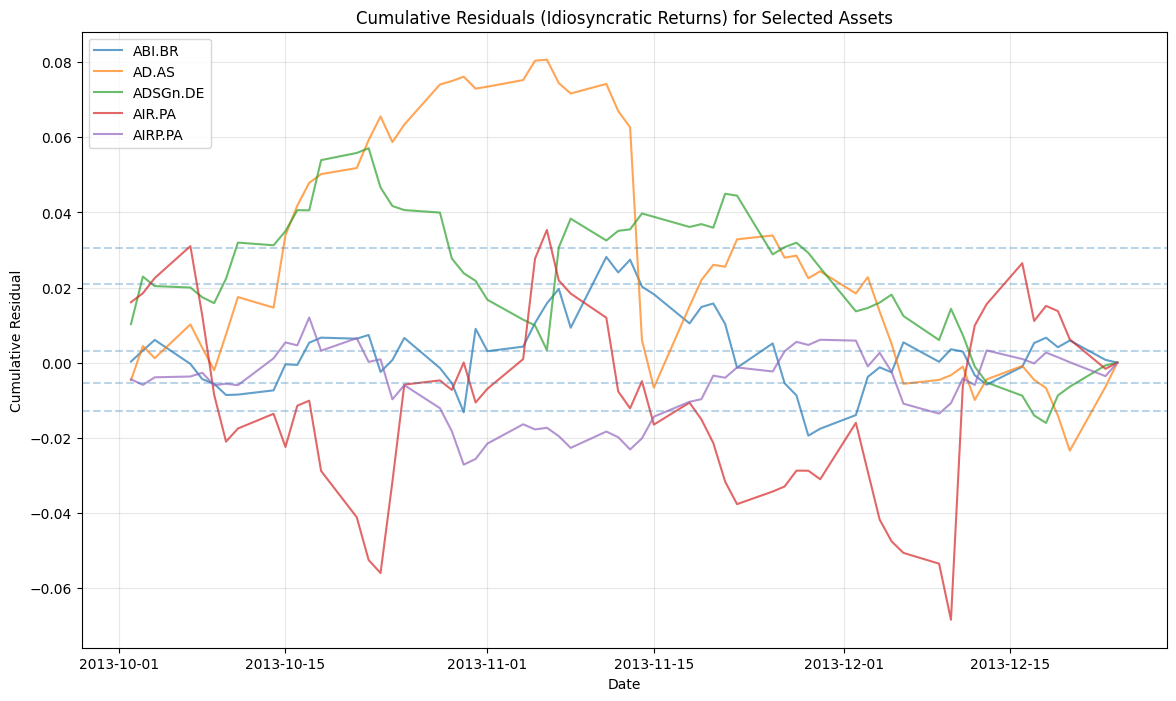

In [9]:
# Plot cumulative residuals for a few assets
sample_assets = list(cumulative_residuals.columns)[:5]

plt.figure(figsize=(14, 8))
for asset in sample_assets:
    plt.plot(
        cumulative_residuals.index, cumulative_residuals[asset], label=asset, alpha=0.7
    )
    # Add equilibrium level
    m = ou_params[asset]["m"]
    plt.axhline(y=m, linestyle="--", alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Cumulative Residual")
plt.title("Cumulative Residuals (Idiosyncratic Returns) for Selected Assets")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

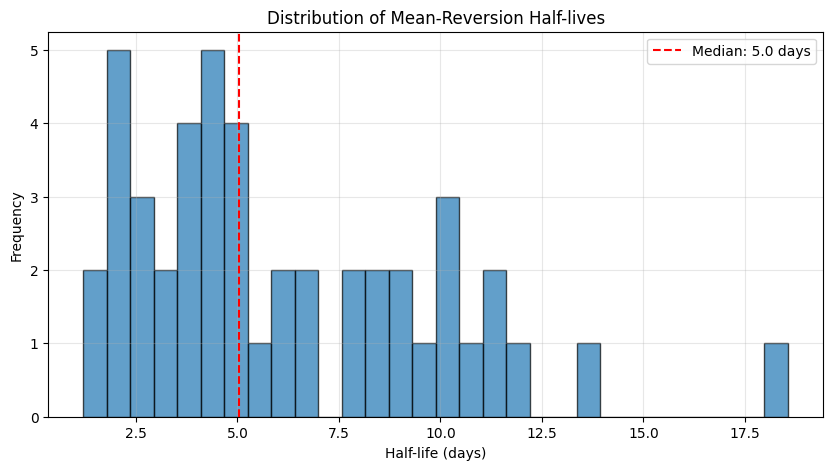

Half-life statistics:
  Mean: 6.2 days
  Median: 5.0 days
  Std: 3.8 days


In [10]:
# Distribution of half-lives
half_lives = pd.Series(
    {asset: params["half_life"] * 252 for asset, params in ou_params.items()}
)
half_lives = half_lives[half_lives < 100]  # Filter outliers

plt.figure(figsize=(10, 5))
plt.hist(half_lives, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Half-life (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Mean-Reversion Half-lives")
plt.axvline(
    half_lives.median(),
    color="r",
    linestyle="--",
    label=f"Median: {half_lives.median():.1f} days",
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Half-life statistics:")
print(f"  Mean: {half_lives.mean():.1f} days")
print(f"  Median: {half_lives.median():.1f} days")
print(f"  Std: {half_lives.std():.1f} days")

# 3. S-Score and Trading Signals

The modified **s-score** measures how far the current cumulative residual is from its equilibrium, accounting for the residual drift:

$$s_{mod, t} = s_t - \frac{\alpha}{\kappa \sigma_{eq}} =  \frac{X_t - m}{\sigma_{eq}} - \frac{\alpha}{\kappa \sigma_{eq}} $$

Trading rules:

- **Buy to Open** (enter long): $s < -s_{bo}$ (price is too low)
- **Sell to Close** (exit long): $s > -s_{bc}$ (price recovered)
- **Sell to Open** (enter short): $s > s_{so}$ (price is too high)
- **Buy to Close** (exit short): $s < s_{sc}$ (price reverted)


In [11]:
# We need to add the alphas to our cumulative residuals in order to compute the S-score
cumulative_alphas = estimate_ou_window_residuals(
    candidate_window, factor_model["factors"], ou_estimation_window
)["alphas"]
for asset in ou_params:
    if asset in cumulative_alphas.index:
        ou_params[asset]["alpha"] = cumulative_alphas[asset]

# Compute s-scores
s_scores = compute_s_score(cumulative_residuals, ou_params, modified=True) # ERROR=>in our function the default is the NOT modified s_scores
                                                                           #        so we have to specify that we want the modified one, as 
                                                                           #        written in the Assignment request

print("S-score statistics across all assets:")
print(
    f"  Mean: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].mean():.2f}"
)
print(
    f"  Std: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].std():.2f}"
)
print(f"  Min: {np.nanmin(s_scores.values):.2f}")
print(f"  Max: {np.nanmax(s_scores.values):.2f}")

S-score statistics across all assets:
  Mean: -0.00
  Std: 1.01
  Min: -2.76
  Max: 2.99


# 4. Rolling Backtest of Statistical Arbitrage Strategy

We now implement a rolling backtest where:

1. At each trading day, we re-estimate the factor model (252-day window) and O-U parameters (60-day window)
2. We compute s-scores and update trading positions **maintaining state across days**
3. We track the portfolio performance


In [12]:
# Storage for results
all_positions = {}
all_s_scores = {}
all_ou_params = {}
all_factor_models = {}

current_positions: dict[str, float] = {}

for rebalance_date in performance.index:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < estimation_window
        or cur_performance.shape[1] == 0
    ):
        continue

    reb_date = rebalance_date.to_pydatetime().date()
    print(f"Processing: {reb_date}")

    # 1. Estimate factor model
    factor_model = estimate_factor_model(cur_performance, n_factors=n_factors)
    all_factor_models[reb_date] = factor_model

    # 2. Compute the residuals needed to estimate the mean-reversion parameters (copied and pasted form box[8])
    cum_residuals_ou = estimate_ou_window_residuals(
        cur_performance, factor_model["factors"], ou_estimation_window
    )["residuals"].cumsum()

    # 3. Estimate O-U parameters
    ou_params = estimate_all_ou_parameters(
        cum_residuals_ou, dt=1 / 252, center_ou_means=False
    )               # As requested by the assignment we do NOT do the de-mean
    all_ou_params[reb_date] = ou_params       

    # 4. Filter assets
    # as requested by the assignment we select the assets with mean regression speed greater than 8.4, which
    # is the min_mean_reversion_speed in our case
    valid_assets = [
        asset
        for asset, parameter in ou_params.items()
        if parameter["kappa"] > min_mean_reversion_speed
    ]

    # 5. S-score
    # We need to add the alphas to our cumulative residuals in order to compute the S-score
    cumulative_alphas = estimate_ou_window_residuals(
        cur_performance, factor_model["factors"], ou_estimation_window
    )["alphas"]
    for asset in ou_params:
        if asset in cumulative_alphas.index:
            ou_params[asset]["alpha"] = cumulative_alphas[asset]

    # We compute the MODIFIED s-scores as requested by the assignment, so we have to specify it in the input of the function:
    s_scores = compute_s_score(cum_residuals_ou, ou_params, modified=True)
    cur_s_scores = s_scores.iloc[-1] # prendiamo solo l's-score di oggi
    all_s_scores[reb_date] = cur_s_scores

    # Update positions carrying over previous day's state
    current_positions = update_positions(
        current_positions=current_positions,
        cur_s_scores=cur_s_scores,
        valid_assets=valid_assets,
        s_bo=s_bo,
        s_so=s_so,
        s_bc=s_bc,
        s_sc=s_sc,
    )
    all_positions[reb_date] = current_positions.copy()

Processing: 2013-12-24
Processing: 2013-12-27
Processing: 2013-12-30
Processing: 2013-12-31
Processing: 2014-01-02
Processing: 2014-01-03
Processing: 2014-01-06
Processing: 2014-01-07
Processing: 2014-01-08
Processing: 2014-01-09
Processing: 2014-01-10
Processing: 2014-01-13
Processing: 2014-01-14
Processing: 2014-01-15
Processing: 2014-01-16
Processing: 2014-01-17
Processing: 2014-01-20
Processing: 2014-01-21
Processing: 2014-01-22
Processing: 2014-01-23
Processing: 2014-01-24
Processing: 2014-01-27
Processing: 2014-01-28
Processing: 2014-01-29
Processing: 2014-01-30
Processing: 2014-01-31
Processing: 2014-02-03
Processing: 2014-02-04
Processing: 2014-02-05
Processing: 2014-02-06
Processing: 2014-02-07
Processing: 2014-02-10
Processing: 2014-02-11
Processing: 2014-02-12
Processing: 2014-02-13
Processing: 2014-02-14
Processing: 2014-02-17
Processing: 2014-02-18
Processing: 2014-02-19
Processing: 2014-02-20
Processing: 2014-02-21
Processing: 2014-02-24
Processing: 2014-02-25
Processing:

In [13]:
# Build portfolio weights time series
positions_df = pd.DataFrame(all_positions).T
positions_df.index = pd.to_datetime(positions_df.index)
positions_df = positions_df.fillna(0)

# Equal weight among active positions
weights = compute_portfolio_weights(positions_df)

print("Position statistics:")
print(f"  Total rebalance dates: {len(positions_df)}")
print(
    f"  Average number of long positions: {(positions_df > 0).sum(axis=1).mean():.1f}"
)
print(
    f"  Average number of short positions: {(positions_df < 0).sum(axis=1).mean():.1f}"
)
print(f"  Average total positions: {(positions_df != 0).sum(axis=1).mean():.1f}")

Position statistics:
  Total rebalance dates: 2347
  Average number of long positions: 0.1
  Average number of short positions: 0.2
  Average total positions: 0.3


In [14]:
# Backtest the strategy
cumulative_returns = backtest(weights, performance)
cumulative_returns_with_costs = backtest(
    weights, performance, transaction_costs=transaction_costs
)

# Compute strategy statistics
stats = compute_strategy_statistics(cumulative_returns.dropna())

print("Strategy Performance:")
print(f"  Total Return: {stats['total_return']:.2%}")
print(f"  Annualized Return: {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats['max_drawdown']:.2%}")

Strategy Performance:
  Total Return: 3.15%
  Annualized Return: 0.33%
  Annualized Volatility: 19.14%
  Sharpe Ratio: 0.02
  Maximum Drawdown: -63.90%


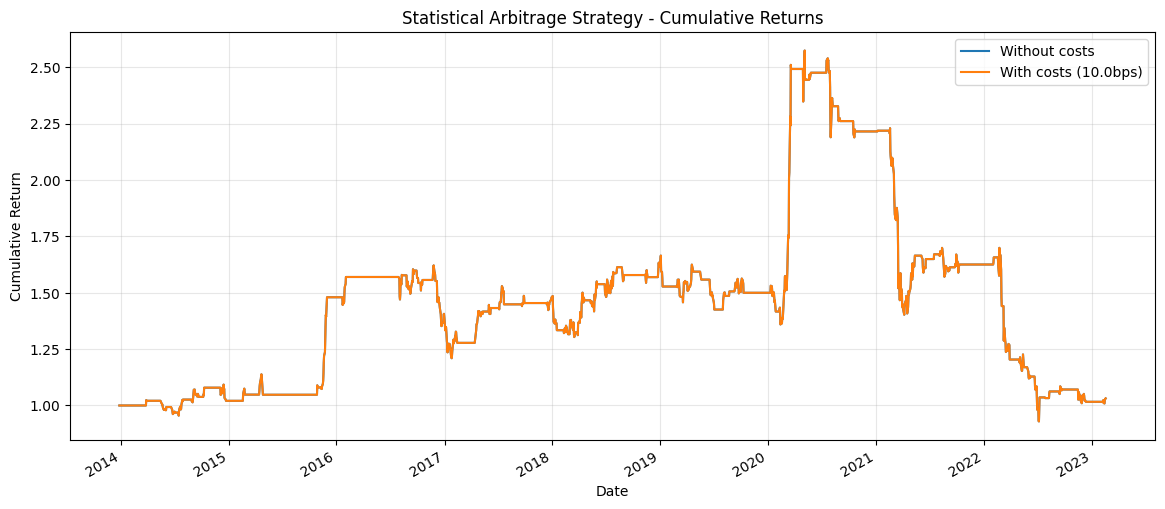

In [15]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Without costs", linewidth=1.5)
cumulative_returns_with_costs.plot(
    label=f"With costs ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

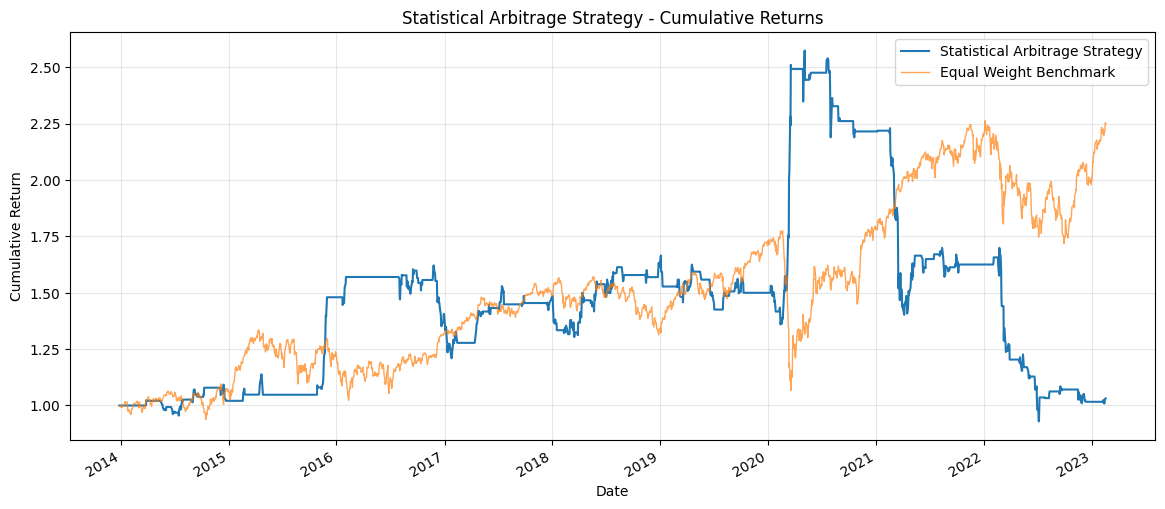

In [16]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Statistical Arbitrage Strategy", linewidth=1.5)

# Add benchmark (equal-weighted portfolio)
equal_weight_benchmark = (1 + performance.mean(axis=1)).cumprod()
equal_weight_benchmark = equal_weight_benchmark.reindex(
    cumulative_returns.index
).ffill()
equal_weight_benchmark = (
    equal_weight_benchmark / equal_weight_benchmark.iloc[0] * cumulative_returns.iloc[0]
)
equal_weight_benchmark.plot(label="Equal Weight Benchmark", linewidth=1, alpha=0.7)


plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

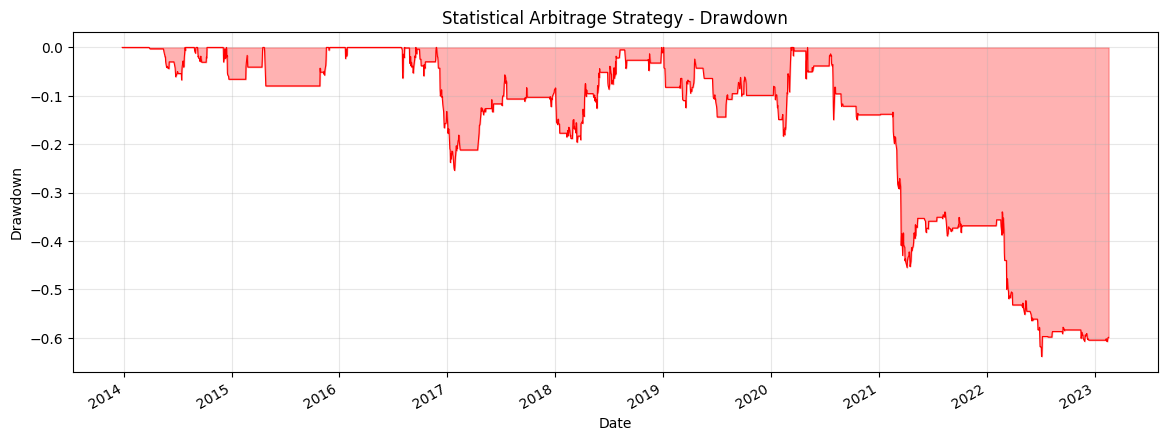

In [17]:
# Plot drawdown
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max

plt.figure(figsize=(14, 5))
drawdown.plot(color="red", linewidth=0.8)
plt.fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Statistical Arbitrage Strategy - Drawdown")
plt.grid(alpha=0.3)
plt.show()

# 5. Analysis of Strategy Characteristics


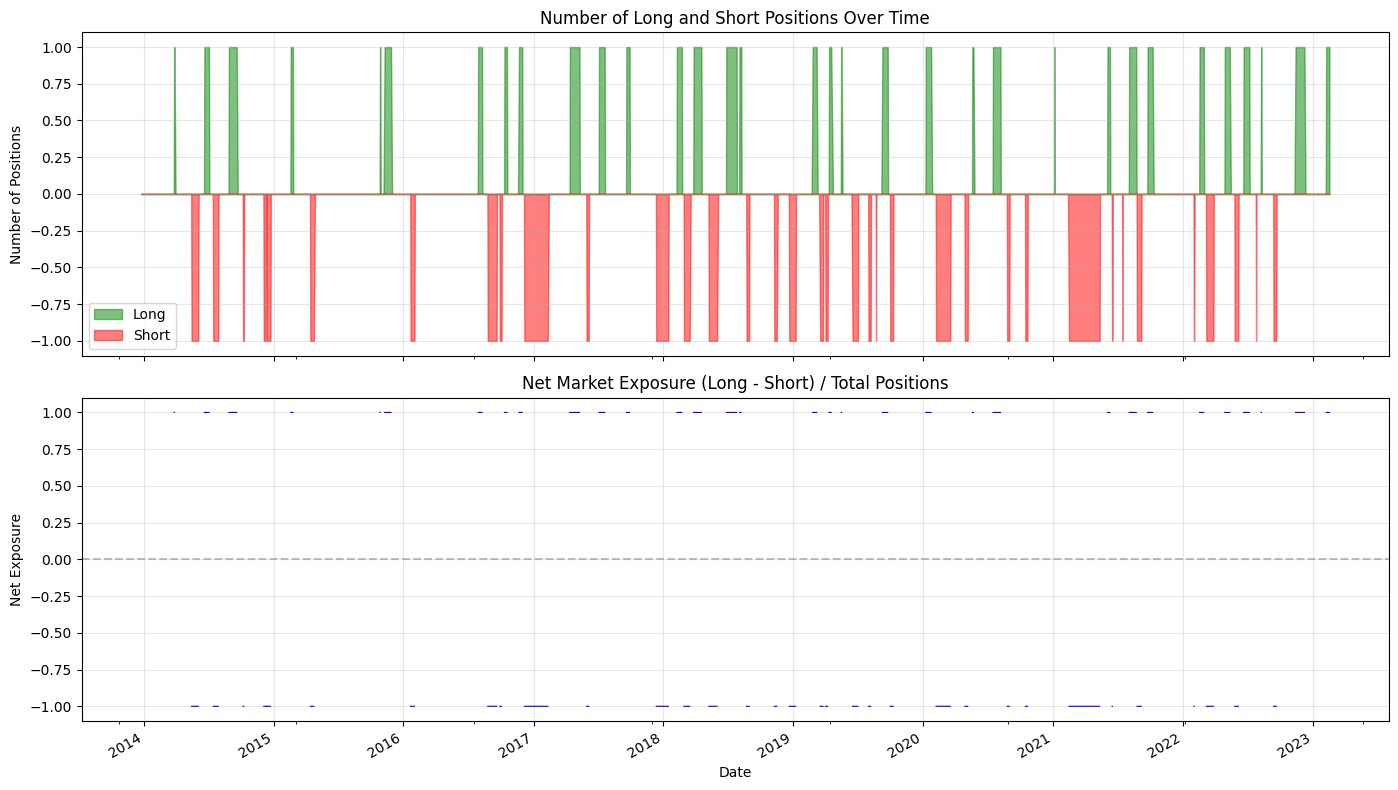

In [18]:
# Number of positions over time
n_long = (positions_df > 0).sum(axis=1)
n_short = (positions_df < 0).sum(axis=1)
n_total = (positions_df != 0).sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(n_long.index, 0, n_long.values, color="green", alpha=0.5, label="Long")
ax1.fill_between(
    n_short.index, 0, -n_short.values, color="red", alpha=0.5, label="Short"
)
ax1.set_ylabel("Number of Positions")
ax1.set_title("Number of Long and Short Positions Over Time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
net_exposure = positions_df.sum(axis=1) / n_total.replace(0, np.nan)
net_exposure.plot(ax=ax2, color="blue", linewidth=0.8)
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Net Exposure")
ax2.set_xlabel("Date")
ax2.set_title("Net Market Exposure (Long - Short) / Total Positions")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

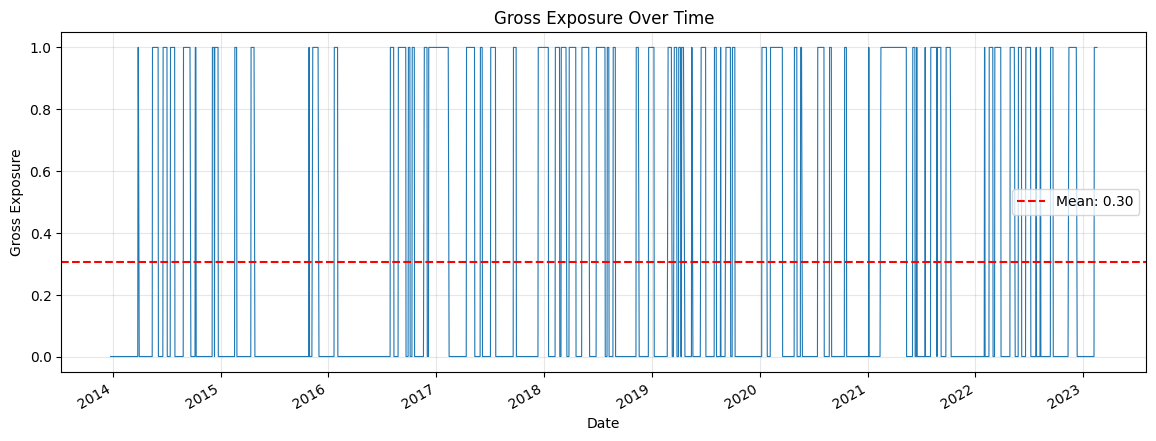

In [19]:
# Gross exposure over time
gross_exposure = weights.abs().sum(axis=1).round(6)

plt.figure(figsize=(14, 5))
gross_exposure.plot(linewidth=0.8)
plt.axhline(
    y=gross_exposure.mean(),
    color="r",
    linestyle="--",
    label=f"Mean: {gross_exposure.mean():.2f}",
)
plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

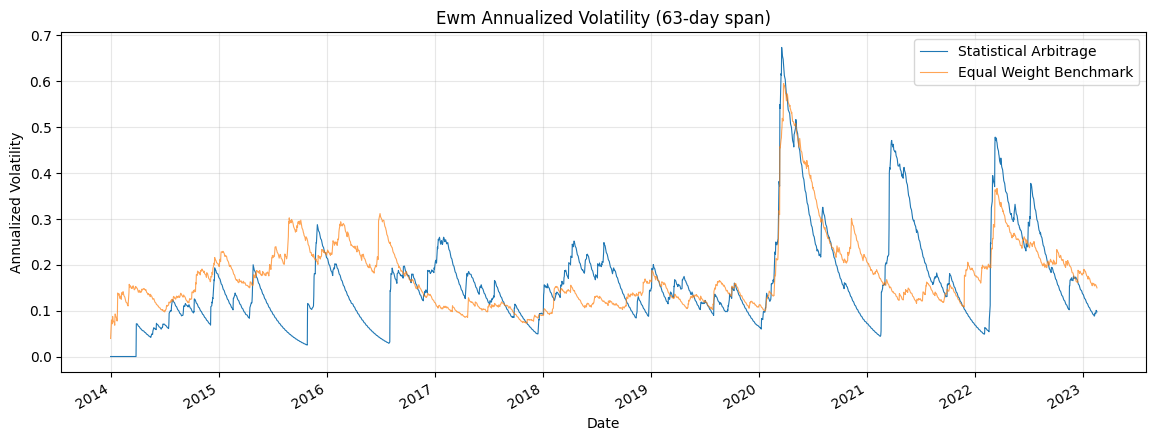

In [20]:
# Ewm volatility of strategy returns
strategy_returns = cumulative_returns.pct_change().dropna()
ewm_vol = strategy_returns.ewm(span=63).std() * np.sqrt(252)

benchmark_returns = equal_weight_benchmark.pct_change().dropna()
benchmark_ewm_vol = benchmark_returns.ewm(span=63).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
ewm_vol.plot(label="Statistical Arbitrage", linewidth=0.8)
benchmark_ewm_vol.plot(label="Equal Weight Benchmark", linewidth=0.8, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Ewm Annualized Volatility (63-day span)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Sensitivity Analysis

## 6.1 Sensitivity to s-score entry threshold


In [21]:
# !!! COMPLETE AS APPROPRIATE !!!

## 6.2 Fixed factors vs variable factor selection


In [22]:
# !!! COMPLETE AS APPROPRIATE !!!

# 7 Trading Time: Volume-Adjusted Returns

### Trading Time

The paper proposes measuring returns in **trading time** rather than calendar time.
The idea: price moves on low-volume days carry more information than moves on high-volume days.

The adjusted return:

$$\bar{R}_{i,t} = R_{i,t} \cdot \frac{\langle \delta V_i \rangle}{V_{i,t}}$$

where $\langle \delta V_i \rangle$ is the trailing average daily volume and $V_{i,t}$ is the actual volume on day $t$.

This amplifies price moves on quiet days and dampens moves on heavy-volume days.
We run the full backtest pipeline on these adjusted returns and compare to calendar time.


In [23]:
# !!! COMPLETE AS APPROPRIATE !!!